C:\Users\Gaurang\AppData\Local\Temp\ipykernel_4740\3317090591.py:22: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['date'] = pd.to_datetime(df['date'])


21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step
PICP (Expected ~0.90): 0.9665171898355754
MPIW: 0.050611354
------------------------------


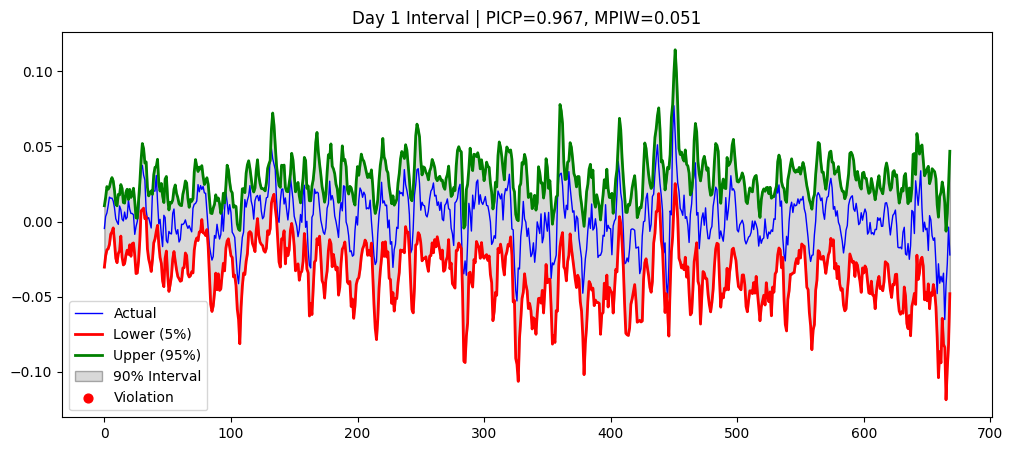

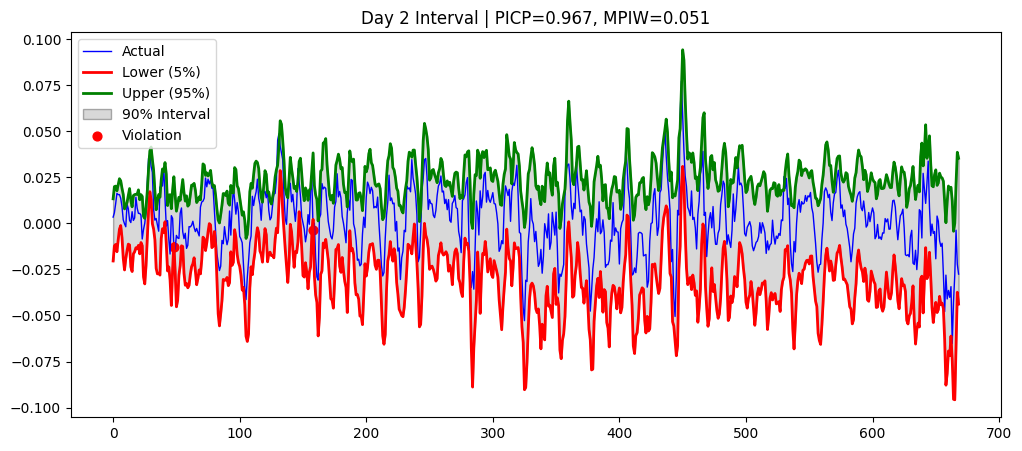

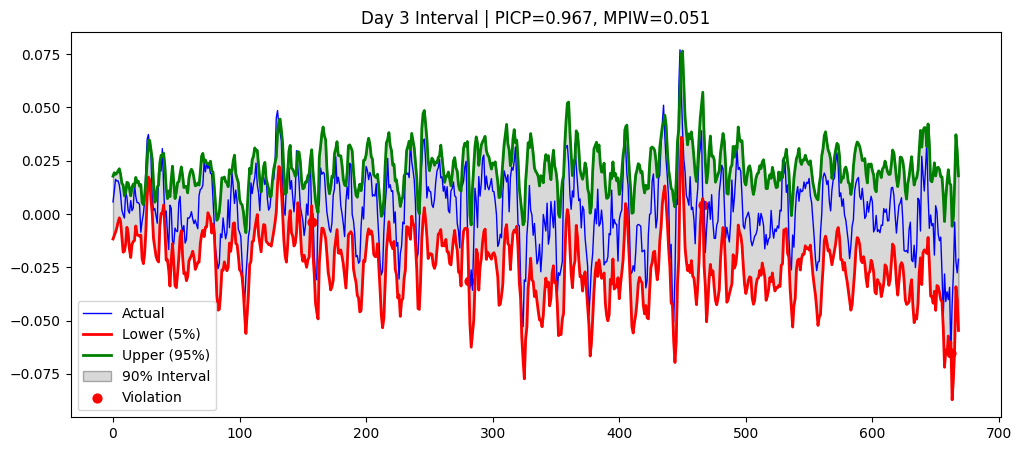

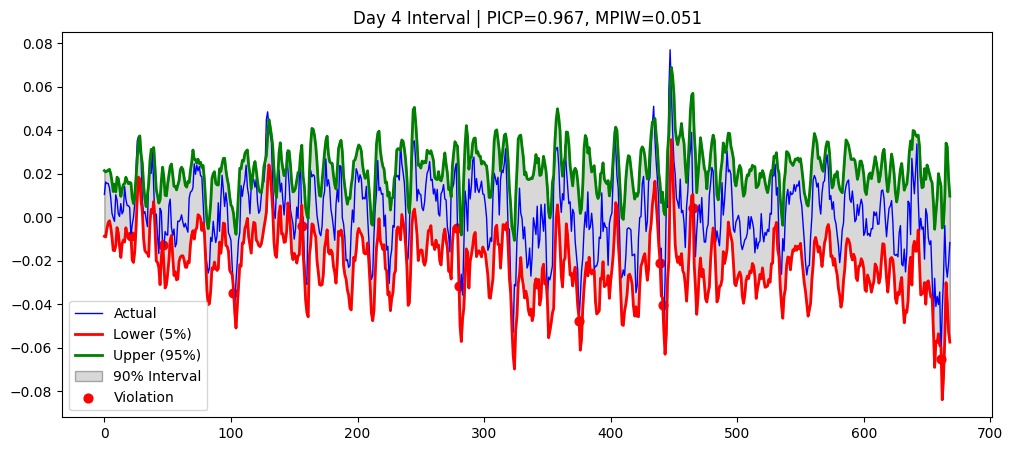

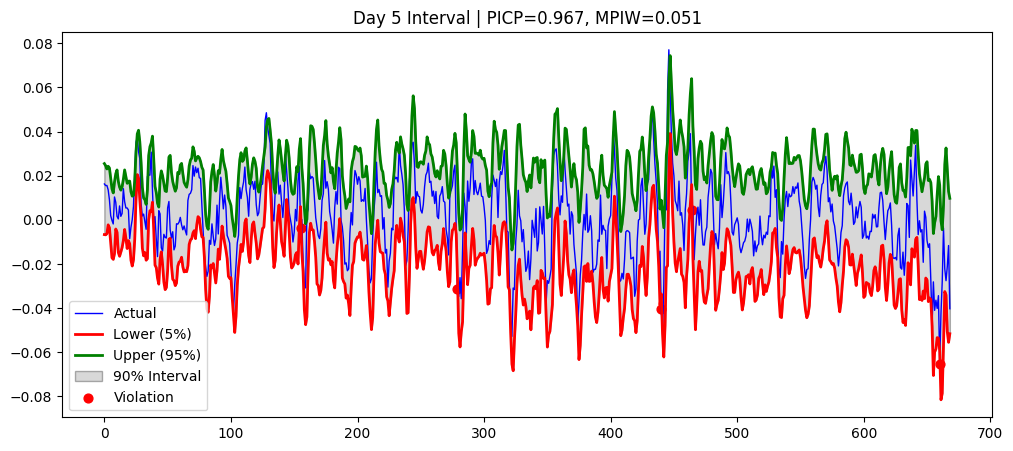

In [8]:
# =========================
# IMPORTS
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import zscore

import tensorflow as tf
from tensorflow.keras.layers import Input, GRU, Dense, Attention, Concatenate, TimeDistributed, Dot, Activation
from tensorflow.keras.models import Model

# =========================
# LOAD DATA
# =========================
df = pd.read_csv("D:\\COLLEGE\\DAIICT\\Semester-2\\Applied Forecasting\\re_implemented_project\\data\\nifty50_with_sector_returns_yfinance1.csv")

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').set_index('date')

df = df[~df.index.duplicated()]
df = df.ffill().bfill()
df = df[(np.abs(zscore(df)) < 3).all(axis=1)]

# =========================
# FEATURE ENGINEERING
# =========================
df['return'] = df['close'].pct_change(5)
df = df.dropna()

for lag in range(1, 6):
    df[f'return_lag_{lag}'] = df['return'].shift(lag)

df['rolling_mean_5'] = df['return'].rolling(5).mean()
df['rolling_std_5'] = df['return'].rolling(5).std()

df['momentum'] = df['close'] - df['close'].shift(5)

delta = df['close'].diff()
gain = delta.clip(lower=0).rolling(14).mean()
loss = -delta.clip(upper=0).rolling(14).mean()
df['RSI'] = 100 - (100 / (1 + gain/loss))

df['EMA_10'] = df['close'].ewm(span=10).mean()
df['volatility'] = df['return'].rolling(10).std()

df['bank_trend'] = df['nifty_bank_ret'].rolling(5).mean()
df['it_trend'] = df['nifty_it_ret'].rolling(5).mean()

df = df.dropna()

# =========================
# DATA PREP
# =========================
features = df.columns.tolist()
features.remove('return')

X = df[features]
y = df['return']

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1,1))

def create_dataset(X, y, n_steps=20, horizon=5):
    Xs, ys = [], []
    for i in range(len(X) - n_steps - horizon):
        Xs.append(X[i:i+n_steps])
        ys.append(y[i+n_steps:i+n_steps+horizon])
    return np.array(Xs), np.array(ys)

n_steps = 20
horizon = 5

X_seq, y_seq = create_dataset(X_scaled, y_scaled, n_steps, horizon)

split = int(0.8 * len(X_seq))
X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]

y_train = y_train.reshape(-1, horizon, 1)
y_test = y_test.reshape(-1, horizon, 1)

# =========================
# TEACHER FORCING
# =========================
def create_decoder_input(y):
    decoder_input = np.zeros_like(y)
    decoder_input[:, 1:, :] = y[:, :-1, :]
    return decoder_input

decoder_input_train = create_decoder_input(y_train)
decoder_input_test = create_decoder_input(y_test)

# =========================
# QUANTILE LOSS
# =========================
def quantile_loss(q):
    def loss(y_true, y_pred):
        e = y_true - y_pred
        return tf.reduce_mean(tf.maximum(q*e, (q-1)*e))
    return loss

# =========================
# MODEL
# =========================
def build_seq2seq_attn(n_steps, n_features, horizon, units, lr, q):
    enc_in = Input(shape=(n_steps, n_features))
    enc_out, state = GRU(units, return_sequences=True, return_state=True)(enc_in)

    dec_in = Input(shape=(horizon,1))
    dec_out = GRU(units, return_sequences=True)(dec_in, initial_state=state)

    score = Dot(axes=[2,2])([dec_out, enc_out])
    weights = Activation('softmax')(score)
    context = Dot(axes=[2,1])([weights, enc_out])

    comb = Concatenate()([context, dec_out])
    out = TimeDistributed(Dense(1))(comb)

    model = Model([enc_in, dec_in], out)
    model.compile(optimizer=tf.keras.optimizers.Adam(lr), loss=quantile_loss(q))
    return model

# =========================
# TRAIN MODELS
# =========================
model_low = build_seq2seq_attn(n_steps, X_train.shape[2], horizon, 128, 0.0005, q=0.05)
model_high = build_seq2seq_attn(n_steps, X_train.shape[2], horizon, 128, 0.0005, q=0.95)

model_low.fit([X_train, decoder_input_train], y_train, epochs=30, batch_size=32, verbose=0)
model_high.fit([X_train, decoder_input_train], y_train, epochs=30, batch_size=32, verbose=0)

# =========================
# PREDICTIONS
# =========================
pred_low = model_low.predict([X_test, decoder_input_test])
pred_high = model_high.predict([X_test, decoder_input_test])

# =========================
# INVERSE SCALING
# =========================
y_true = scaler_y.inverse_transform(y_test.reshape(-1,1)).reshape(-1,horizon)
VaR_low = scaler_y.inverse_transform(pred_low.reshape(-1,1)).reshape(-1,horizon)
VaR_high = scaler_y.inverse_transform(pred_high.reshape(-1,1)).reshape(-1,horizon)

# =========================
# PICP & MPIW
# =========================
def picp(y, low, high):
    return np.mean((y >= low) & (y <= high))

def mpiw(low, high):
    return np.mean(high - low)

PICP = picp(y_true, VaR_low, VaR_high)
MPIW = mpiw(VaR_low, VaR_high)

print("PICP (Expected ~0.90):", PICP)
print("MPIW:", MPIW)
print("-"*30)

# =========================
# VISUALIZATION
# =========================
for i in range(horizon):
    plt.figure(figsize=(12,5))

    plt.plot(y_true[:,i], label="Actual", color='blue', linewidth=1)
    plt.plot(VaR_low[:,i], label="Lower (5%)", color='red',linewidth=2)
    plt.plot(VaR_high[:,i], label="Upper (95%)", color='green',linewidth=2)

    plt.fill_between(
        range(len(y_true)),
        VaR_low[:,i],
        VaR_high[:,i],
        color='gray',
        alpha=0.3,
        label="90% Interval",
        edgecolor = 'black'
    )

    violations = y_true[:,i] < VaR_low[:,i]
    idx = np.where(violations)[0]

    plt.scatter(
        idx,
        y_true[idx, i],
        color='red',
        label="Violation",
        s=40
    )

    plt.title(f"Day {i+1} Interval | PICP={PICP:.3f}, MPIW={MPIW:.3f}")
    plt.legend()
    plt.show()